**PROJECT: SEPSIS PREDICTION USING MACHINE LEARNING**

**Objective**

**Problem Statement**
Sepsis is a life-threatening medical emergency caused by the body’s extreme response to an infection. Early detection is critical to improving patient outcomes and reducing mortality.


**Objective**: To build a machine learning model that accurately predicts whether a patient is at risk of developing sepsis based on clinical features. This will aid healthcare providers in making timely decisions and initiating interventions.


**Dataset Description**

The dataset contains anonymized medical records of patients with the following details:

**Observational Features**: Vital signs (e.g., heart rate, blood pressure, oxygen saturation), laboratory measurements, and other clinical indicators.

**Target Variable**: 'SepsisLabel' a binary indicator (0 = no sepsis, 1 = sepsis)

**Temporal Information**: Each patient may have multiple records over time.

The goal is to use these features to classify whether a patient will develop sepsis.


**A PROJECT TO PREDICT SEPSIS BEFORE IT HAPPENS**

Import Libraries

**python**
import pandas as pd
df = pd.read_csv('sepsis_data.csv')
df.fillna(method='ffill', inplace=True)


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import SelectKBest, f_classif
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.initializers import Constant
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline

import json
import joblib


**Data Loading & Preprocessing**

This section involves:
- Importing required libraries (e.g., pandas, numpy, sklearn)
- Loading patient data from CSV/TSV files
- Handling missing values with imputation strategies (mean/forward fill, etc.)
- Filtering or aggregating time-series data (e.g., selecting last available record or statistical summaries)
- Removing duplicates and irrelevant features



Load Dataset From Kaggle

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os
import zipfile

# Paths
checkpoint_dir = "/content/drive/MyDrive/model_checkpoints/"
os.makedirs(checkpoint_dir, exist_ok=True)

progress_file = os.path.join(checkpoint_dir, 'progress.json')
results_file = os.path.join(checkpoint_dir, 'results.csv')

# Load progress if it exists
if os.path.exists(progress_file):
    with open(progress_file, 'r') as f:
        progress = json.load(f)
else:
    progress = {}

Unzip file

In [ ]:
import os
import zipfile

# create kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)



In [ ]:
# Move kaggle.json to the right location
!mv kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d salikhussaini49/prediction-of-sepsis

!unzip prediction-of-sepsis.zip

Streaming output truncated to the last 5000 lines.
  inflating: training_setB/training_setB/p115003.psv  
  inflating: training_setB/training_setB/p115004.psv  
  inflating: training_setB/training_setB/p115005.psv  
  inflating: training_setB/training_setB/p115006.psv  
  inflating: training_setB/training_setB/p115007.psv  
  inflating: training_setB/training_setB/p115008.psv  
  inflating: training_setB/training_setB/p115009.psv  
  inflating: training_setB/training_setB/p115010.psv  
  inflating: training_setB/training_setB/p115011.psv  
  inflating: training_setB/training_setB/p115012.psv  
  inflating: training_setB/training_setB/p115013.psv  
  inflating: training_setB/training_setB/p115014.psv  
  inflating: training_setB/training_setB/p115015.psv  
  inflating: training_setB/training_setB/p115016.psv  
  inflating: training_setB/training_setB/p115017.psv  
  inflating: training_setB/training_setB/p115018.psv  
  inflating: training_setB/training_setB/p115019.psv  
  inflating: t

Explore Data

In [ ]:
# Step 1: Load Data
df = pd.read_csv('Dataset.csv')

# Display dataset information
print("DataFrame Head:\n")
print(df.head(5), '\n')
print("Shape of DataFrame:", df.shape, '\n')
print('--------------------')
print("Dataset Information:\n")
print(df.info(), '\n')
print('--------------------')
print("Missing Values in Dataset:\n")
print(df.isnull().sum())

DataFrame Head:

   Unnamed: 0  Hour    HR  O2Sat  Temp    SBP   MAP   DBP  Resp  EtCO2  ...  \
0           0     0   NaN    NaN   NaN    NaN   NaN   NaN   NaN    NaN  ...   
1           1     1  65.0  100.0   NaN    NaN  72.0   NaN  16.5    NaN  ...   
2           2     2  78.0  100.0   NaN    NaN  42.5   NaN   NaN    NaN  ...   
3           3     3  73.0  100.0   NaN    NaN   NaN   NaN  17.0    NaN  ...   
4           4     4  70.0  100.0   NaN  129.0  74.0  69.0  14.0    NaN  ...   

   Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0         NaN        NaN  68.54       0    NaN    NaN        -0.02       1   
1         NaN        NaN  68.54       0    NaN    NaN        -0.02       2   
2         NaN        NaN  68.54       0    NaN    NaN        -0.02       3   
3         NaN        NaN  68.54       0    NaN    NaN        -0.02       4   
4         NaN      330.0  68.54       0    NaN    NaN        -0.02       5   

   SepsisLabel  Patient_ID  
0         

**Preprocessing**

Drop Columns and Handle Missing Data

In [ ]:
# Drop column index 0)
df = df.drop(columns=[df.columns[0]])

# Step 3: Impute missing values
df.fillna(df.median(), inplace=True)
print("Missing Values After Handling:")
print(df.isnull().sum())

Missing Values After Handling:
HR                  0
O2Sat               0
Temp                0
SBP                 0
MAP                 0
DBP                 0
Resp                0
EtCO2               0
BaseExcess          0
HCO3                0
FiO2                0
pH                  0
PaCO2               0
SaO2                0
AST                 0
BUN                 0
Alkalinephos        0
Calcium             0
Chloride            0
Creatinine          0
Bilirubin_direct    0
Glucose             0
Lactate             0
Magnesium           0
Phosphate           0
Potassium           0
Bilirubin_total     0
TroponinI           0
Hct                 0
Hgb                 0
PTT                 0
WBC                 0
Fibrinogen          0
Platelets           0
Age                 0
Gender              0
Unit1               0
Unit2               0
HospAdmTime         0
ICULOS              0
SepsisLabel         0
Patient_ID          0
dtype: int64


Visualize Class Distribution

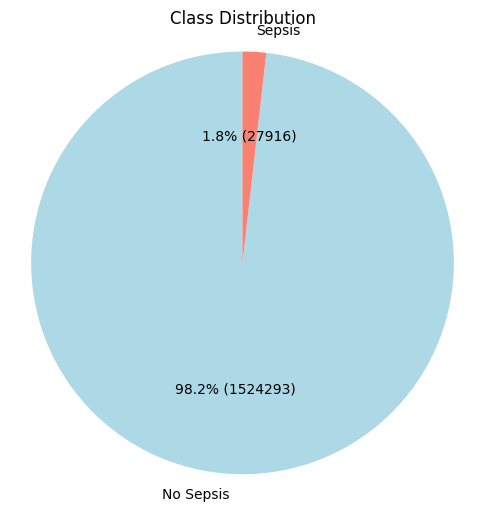

In [ ]:
# Plot class distribution using a pie chart
class_counts = df['SepsisLabel'].value_counts()
labels = ['No Sepsis', 'Sepsis']
sizes = class_counts.values
colors = ['lightblue', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors,
        autopct=lambda pct: f'{pct:.1f}% ({int(pct/100.*np.sum(sizes))})',
        startangle=90)
plt.title('Class Distribution')
plt.axis('equal')
plt.show()

**Feature Engineering/Data Augmentation**

Steps performed include:

**Feature selection:** Identifying the most relevant predictors for sepsis

**Aggregating patient-level data** if in time-series format

**Normalization** of continuous features (e.g., MinMaxScaler or StandardScaler)


Split data Into Features And Label

In [ ]:
# Split into features and labels
X = df.drop(columns=['SepsisLabel'])  # Features
y = df['SepsisLabel']            # Target variable


print(X.shape)
print(y.shape)



(1552210, 41)
(1552210,)



**Handling imbalance** in the dataset using downsampling. We downsampled the majority class to obtain equal class sizes

python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Downsample Majority Data Class

In [ ]:
# Downsampling
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X, y = rus.fit_resample(X, y)

# Print class counts in y after downsampling
print("Class Counts in y after downsampling:", np.bincount(y))


Class Counts in y after downsampling: [27916 27916]


Normalize Feature Values

In [ ]:
# Normalize Features
scaler = StandardScaler()
features = [col for col in df.columns if col != 'SepsisLabel']

# Apply StandardScaler to the pandas DataFrame
df[features] = scaler.fit_transform(df[features])

print("First five rows after normalization:")
print(df.head())

First five rows after normalization:
         HR     O2Sat      Temp       SBP       MAP       DBP      Resp  \
0 -0.059244  0.254653  0.017198 -0.109313 -0.137238 -0.108390 -0.130901   
1 -1.183861  0.981435  0.017198 -0.109313 -0.659735 -0.108390 -0.450200   
2 -0.393590  0.981435  0.017198 -0.109313 -2.586445 -0.108390 -0.130901   
3 -0.697540  0.981435  0.017198 -0.109313 -0.137238 -0.108390 -0.343767   
4 -0.879911  0.981435  0.017198  0.262891 -0.529111  0.495331 -0.982365   

      EtCO2  BaseExcess      HCO3  ...  Fibrinogen  Platelets       Age  \
0  0.001026    0.036958 -0.003530  ...   -0.019286  -0.034967  0.398538   
1  0.001026    0.036958 -0.003530  ...   -0.019286  -0.034967  0.398538   
2  0.001026    0.036958 -0.003530  ...   -0.019286  -0.034967  0.398538   
3  0.001026    0.036958 -0.003530  ...   -0.019286  -0.034967  0.398538   
4  0.001026    0.036958  2.228856  ...   -0.019286   5.806531  0.398538   

    Gender     Unit1     Unit2  HospAdmTime    ICULOS  Sepsis

Split Data Into Training And Testing Sets

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(y_test.shape)

(44665, 41)
(11167,)


**Model Training & Evaluation**

We trained multiple models to evaluate their performance, such as:
- Logistic Regression
- Random Forest
- XGBoost

In [ ]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss')
}

Compile and Train The 3 Selected Models

# Training and Validation Phase

In [ ]:
# Define feature counts to evaluate
feature_counts = list(range(X.shape[1], 9, -5))


best_k = None
best_model = None
best_accuracy = 0.0  # Store the best validation accuracy

for k_features in feature_counts:
    print(f"\nEvaluating models with top {k_features} features...")

    # Feature selection
    selector = SelectKBest(score_func=f_classif, k=k_features)

    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")

        # Downsampling using RandomUnderSampler
        rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
        X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

        # KFold cross-validation for training and validation
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        training_accuracies = []
        validation_accuracies = []

        for train_index, val_index in kf.split(X_train_resampled):
            # Use array indexing instead of .iloc
            X_train_fold, X_val_fold = X_train_resampled[train_index], X_train_resampled[val_index]
            y_train_fold, y_val_fold = y_train_resampled[train_index], y_train_resampled[val_index]

            # Apply feature selection to the fold data
            X_train_fold_sel = selector.fit_transform(X_train_fold, y_train_fold)
            X_val_fold_sel = selector.transform(X_val_fold)

            # Train the model
            model.fit(X_train_fold_sel, y_train_fold)

            # Make predictions on the training and validation folds
            y_train_pred = model.predict(X_train_fold_sel)
            y_val_pred = model.predict(X_val_fold_sel)

            # Calculate training and validation accuracy for the fold
            training_accuracies.append(accuracy_score(y_train_fold, y_train_pred))
            validation_accuracies.append(accuracy_score(y_val_fold, y_val_pred))

        # Average training and validation accuracy across folds
        avg_training_accuracy = np.mean(training_accuracies)
        avg_validation_accuracy = np.mean(validation_accuracies)
        print(f"Average Training Accuracy: {avg_training_accuracy:.4f}")
        print(f"Average Validation Accuracy: {avg_validation_accuracy:.4f}")

        # Save model checkpoint
        model_path = os.path.join(checkpoint_dir, f"{model_name.replace(' ', '_')}_{k_features}_features.pkl")
        joblib.dump(model, model_path)
        print(f"Checkpoint saved: {model_path}")


Evaluating models with top 42 features...

Training Logistic Regression...
Average Training Accuracy: 0.6790
Average Validation Accuracy: 0.6786
Checkpoint saved: /content/drive/MyDrive/model_checkpoints/Logistic_Regression_42_features.pkl

Training Random Forest...
Average Training Accuracy: 1.0000
Average Validation Accuracy: 0.8170
Checkpoint saved: /content/drive/MyDrive/model_checkpoints/Random_Forest_42_features.pkl

Training XGBoost...
Average Training Accuracy: 0.8574
Average Validation Accuracy: 0.7793
Checkpoint saved: /content/drive/MyDrive/model_checkpoints/XGBoost_42_features.pkl

Evaluating models with top 37 features...

Training Logistic Regression...
Average Training Accuracy: 0.6790
Average Validation Accuracy: 0.6777
Checkpoint saved: /content/drive/MyDrive/model_checkpoints/Logistic_Regression_37_features.pkl

Training Random Forest...
Average Training Accuracy: 1.0000
Average Validation Accuracy: 0.8023
Checkpoint saved: /content/drive/MyDrive/model_checkpoints/Ra

Comparative Visualization Of The 3 Models' Performances

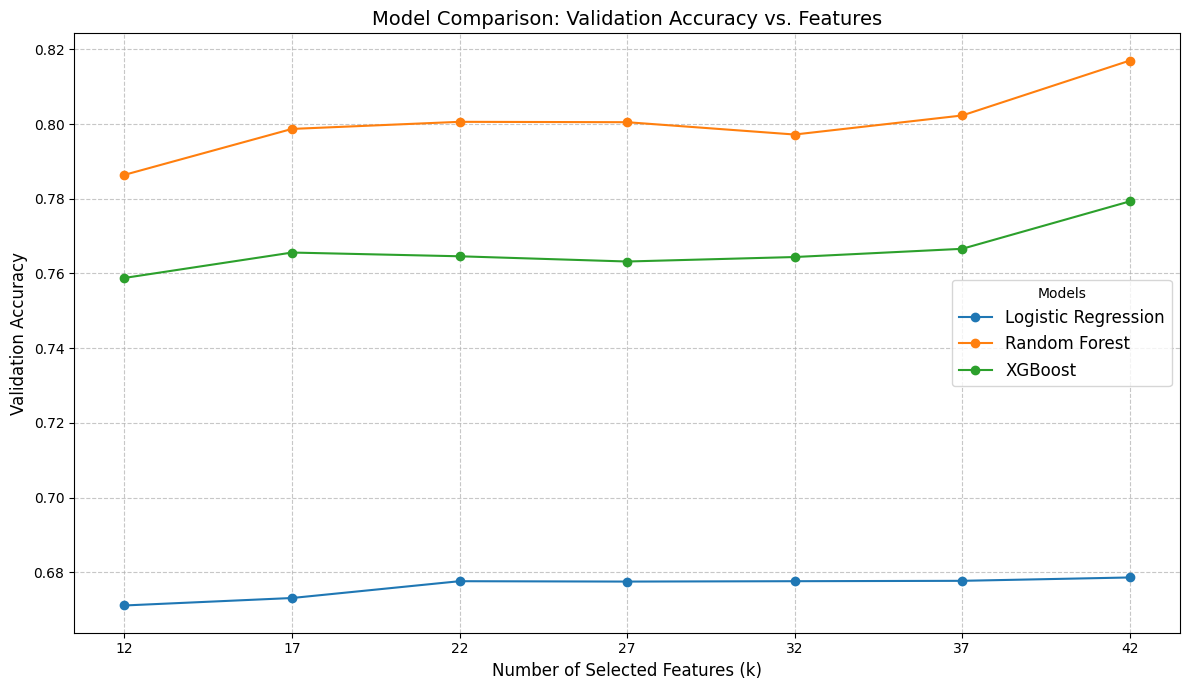

In [ ]:
# Data extracted from validation results
feature_counts = [42, 37, 32, 27, 22, 17, 12]  # Number of features
validation_accuracies = {
    'Logistic Regression': [0.6786, 0.6777, 0.6776, 0.6775, 0.6776, 0.6731, 0.6711],
    'Random Forest': [0.8170, 0.8023, 0.7972, 0.8005, 0.8006, 0.7987, 0.7864],
    'XGBoost': [0.7793, 0.7666, 0.7644, 0.7632, 0.7646, 0.7656, 0.7588]
}

# Plotting line chart to visualize models' performances
plt.figure(figsize=(12, 7))

# Logistic Regression line
plt.plot(feature_counts, validation_accuracies['Logistic Regression'], marker='o', label='Logistic Regression')

# Random Forest line
plt.plot(feature_counts, validation_accuracies['Random Forest'], marker='o', label='Random Forest')

# XGBoost line
plt.plot(feature_counts, validation_accuracies['XGBoost'], marker='o', label='XGBoost')

# Customizing the chart
plt.xlabel('Number of Selected Features (k)', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Model Comparison: Validation Accuracy vs. Features', fontsize=14)
plt.xticks(feature_counts)  # Ensure x-axis shows feature counts clearly
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Models', fontsize=12)
plt.tight_layout()
plt.show()

**Plot Bar Chart to visualize the 3 models' performances**

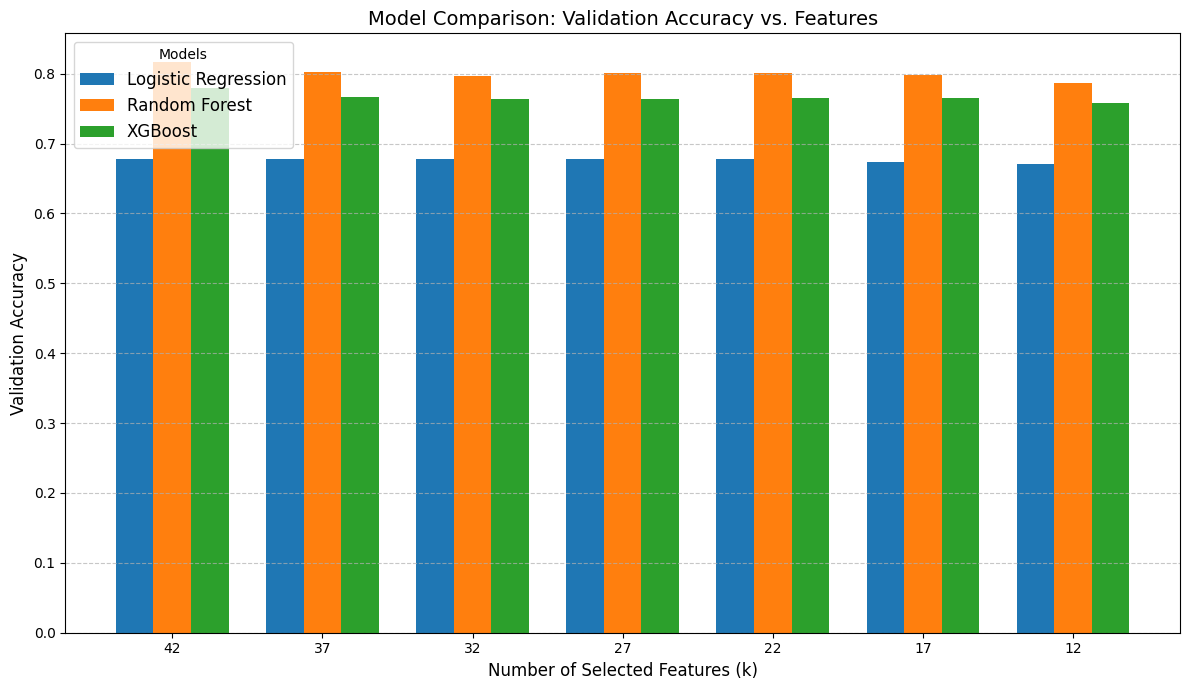

In [ ]:
# Data extracted from validation results
feature_counts = [42, 37, 32, 27, 22, 17, 12]  # Number of features
validation_accuracies = {
    'Logistic Regression': [0.6786, 0.6777, 0.6776, 0.6775, 0.6776, 0.6731, 0.6711],
    'Random Forest': [0.8170, 0.8023, 0.7972, 0.8005, 0.8006, 0.7987, 0.7864],
    'XGBoost': [0.7793, 0.7666, 0.7644, 0.7632, 0.7646, 0.7656, 0.7588]
}

# Bar width for each group
bar_width = 0.25
x = np.arange(len(feature_counts))  # x-axis positions for bars

# Plotting the bar chart
plt.figure(figsize=(12, 7))

# Logistic Regression bars
plt.bar(x - bar_width, validation_accuracies['Logistic Regression'], width=bar_width, label='Logistic Regression')

# Random Forest bars
plt.bar(x, validation_accuracies['Random Forest'], width=bar_width, label='Random Forest')

# XGBoost bars
plt.bar(x + bar_width, validation_accuracies['XGBoost'], width=bar_width, label='XGBoost')

# Customizing the chart
plt.xlabel('Number of Selected Features (k)', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Model Comparison: Validation Accuracy vs. Features', fontsize=14)
plt.xticks(x, feature_counts)  # Ensure x-axis shows feature counts clearly
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Models', fontsize=12)
plt.tight_layout()
plt.show()

Display Plots of Feature Importance

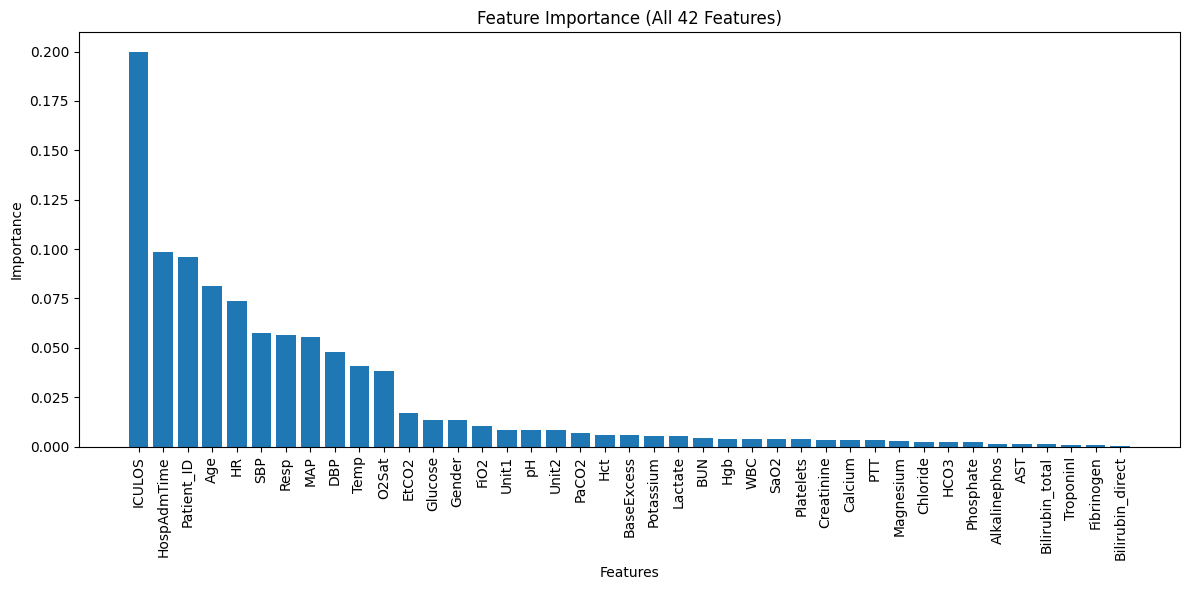

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
import joblib
import matplotlib.pyplot as plt


# First, you need to train a RandomForestClassifier on all features
rf_all_features = RandomForestClassifier(random_state=42)  # Initialize the model
rf_all_features.fit(X_train, y_train)  # Train the model on your training data (X_train, y_train)

# Now you can get the feature importances
importances = rf_all_features.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': df.drop(columns=['SepsisLabel']).columns, 'Importance': importances})  # Use original feature names
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (All 42 Features)")
plt.tight_layout()
plt.show()

Display the 17 KBest Features

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Feature Selection with SelectKBest
selector = SelectKBest(score_func=f_classif, k=17)

# Fit and transform on training data
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)  # Transform test data

# Get selected feature names (from original DataFrame 'df')
selected_feature_names = df.drop(columns=['SepsisLabel']).columns[selector.get_support()]
print("Selected Features:", selected_feature_names)

Selected Features: Index(['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'FiO2', 'BUN',
       'Calcium', 'Lactate', 'WBC', 'Gender', 'Unit2', 'HospAdmTime', 'ICULOS',
       'Patient_ID'],
      dtype='object')


Compile And Train Random Forest Classifier Using 17KBest Features with Optimized parameters

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.preprocessing import StandardScaler

# Feature selection with mutual_info_classif
selector = SelectKBest(score_func=mutual_info_classif, k=17)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Scale the selected features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Perform K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
training_scores, validation_scores, validation_aucs = [], [], []

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)

# Store accuracy for each fold
fold_accuracies = []

# Iterate over folds
for fold, (train_index, test_index) in enumerate(kf.split(X_train_scaled, y_train)):
    X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[test_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    # Train the model
    rf_classifier.fit(X_train_fold, y_train_fold)

    # Predict on the validation set
    y_pred = rf_classifier.predict(X_val_fold)
    y_prob = rf_classifier.predict_proba(X_val_fold)[:, 1]

    # Calculate accuracy for this fold
    accuracy = accuracy_score(y_val_fold, y_pred)
    fold_accuracies.append(accuracy)

    # Calculate and store validation accuracy and AUC
    validation_scores.append(accuracy)
    validation_aucs.append(roc_auc_score(y_val_fold, y_prob))

    print(f"Fold {fold + 1} Accuracy: {accuracy}")

# Print average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)
print(f"Average Accuracy: {average_accuracy}")

# Print average validation accuracy and AUC
print(f"\nAverage Validation Accuracy: {np.mean(validation_scores)}")
print(f"Average Validation AUC:\n {np.mean(validation_aucs)}")

# Print classification report for the last fold (for example)
print("\nClassification Report (Last Fold):")
print(classification_report(y_val_fold, y_pred))

Fold 1 Accuracy: 0.8348818985783052
Fold 2 Accuracy: 0.8327549535430426
Fold 3 Accuracy: 0.8409269002574723
Fold 4 Accuracy: 0.8433896787193552
Fold 5 Accuracy: 0.8361132878092467
Average Accuracy: 0.8376133437814843

Average Validation Accuracy: 0.8376133437814843
Average Validation AUC:
 0.9145326212195899

Classification Report (Last Fold):
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      4466
           1       0.82      0.85      0.84      4467

    accuracy                           0.84      8933
   macro avg       0.84      0.84      0.84      8933
weighted avg       0.84      0.84      0.84      8933



Plot Confusion Matrix And ROC Curve

**Evaluation metrics**:
- Accuracy
- Precision, Recall
- F1 Score
- AUC-ROC


**Visualizations**

Visual analytics helped understand the data and interpret model results:
- Distribution plots of clinical features
- Correlation heatmaps
- Confusion matrices
- ROC curves for comparing model performance


<Figure size 400x400 with 0 Axes>

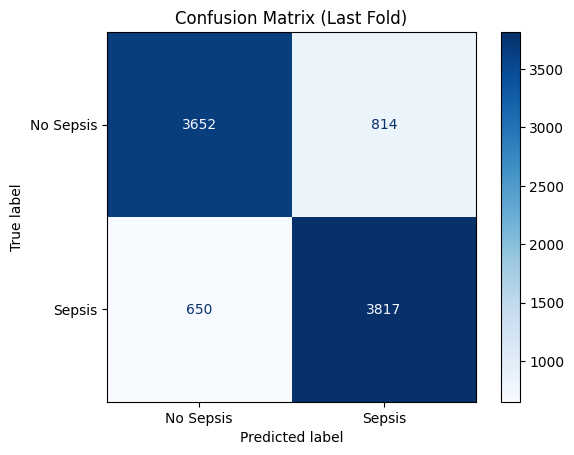

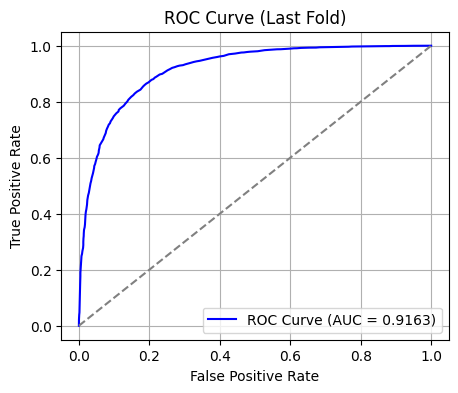

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# Generate the confusion matrix for the last fold
conf_matrix = confusion_matrix(y_val_fold, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(4, 4))
ConfusionMatrixDisplay(conf_matrix, display_labels=["No Sepsis", "Sepsis"]).plot(cmap='Blues')
plt.title("Confusion Matrix (Last Fold)")
plt.show()

# Compute ROC curve and AUC for the last fold
fpr, tpr, thresholds = roc_curve(y_val_fold, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Last Fold)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Prediction

We tested our model on a single patient sample to determine if our model worked.

In [ ]:
# Define the new patient data with the selected features
new_patient_data = {'Hour': 1, 'HR': 0, 'O2Sat': 1, 'Temp': 1, 'SBP': 1, 'MAP': 1, 'DBP': 0, 'Resp': 1, 'FiO2': 1,
                    'BUN': 1, 'Calcium': 1, 'Lactate': 0, 'WBC': 1, 'Gender': 1, 'HospAdmTime': 1, 'ICULOS': 1,
                    'Patient_ID': 1}

# Create a DataFrame for the new patient, using selected_feature_names for column order
new_patient = pd.DataFrame([new_patient_data], columns=selected_feature_names)

# Ensure the column order matches the training dataset
new_patient = new_patient[selected_feature_names]

# Convert the DataFrame to a NumPy array
new_patient_array = new_patient.to_numpy()

# Make predictions
new_prediction = rf_classifier.predict(new_patient_array)
new_probability = rf_classifier.predict_proba(new_patient_array)[:, 1]

# Ground truth (changed to class 1)
ground_truth = 1

# Evaluate prediction correctness
correct_prediction = new_prediction[0] == ground_truth

# Display results
print("\nNew Patient Test Results")
print(f"Sepsis Prediction: {new_prediction[0]}")
print(f"Probability of Sepsis: {new_probability[0]:.4f}")

# Print whether the prediction is correct or incorrect
if correct_prediction:
    print("Correct Prediction")
else:
    print("Incorrect Prediction")


New Patient Test Results
Sepsis Prediction: 1
Probability of Sepsis: 0.7250
Correct Prediction


**Final Results & Discussion**

We have succesfully developed a machine learning model with a good performance at predicting the possibility of sepsis among hospitalized patients.Though its accuracy is not the highest, the model shows a lot of promise as it is among the best performing models in various studies on the dataset from Kaggle. The precision and recall values of 84% is particularly worth mentioning as it is very important in clinical performance, though there is a lot of room for improvement.

**Highlights From Our Model**

- Random Forest achieved an F1 score of 0.84 and ROC-AUC of 0.91, indicating strong performance in predicting sepsis. This is a positive finding and a step to further develop our model to enhance performance.


**Future Works**

We intend to do further data exploration to eliminate redundant and uncorrelated features to enhance prediction.

A more robust hyperparameter tuning will also be performed.

In addition, we will look for a more diverse and balanced dataset, reflecting real clinical patient charactecteristics to enhance our model performance and enable generalization.